In [ ]:
!pip install nilearn
!pip install --upgrade nilearn

# PPI-Finger

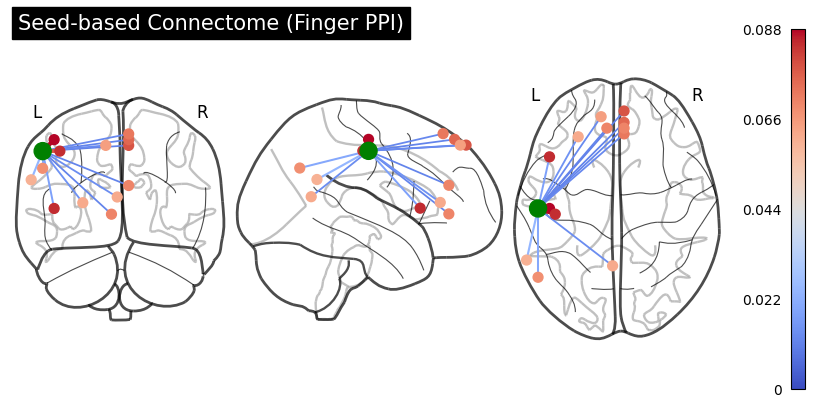

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
from matplotlib import colormaps
from matplotlib.colors import Normalize

# === Dati originali ===
# p = 0.02
coordinates_t = [
    (-46, -16,  54, 3.51),
    (-42, -20,  46, 3.37),
    (-46,  20,   6, 3.38),
    (  6,  52,  50, 3.14),
    (  6,  44,  54, 3.03),
    (  6,  36,  58, 2.90),
    ( -6,  40,   2, 2.81),
    (  6,  40,  22, 2.81),
    (-54, -64,  34, 2.72),
    (-10,  48,  50, 2.58),
    (-26,  34,  10, 2.48),
    (-2,  -56,  14, 2.48),
    (-62, -52,  26, 2.41)
]

# 1) Definiamo il seed
seed_coord = (-54, -16, 46)
seed_t     = 0.0

# 2) Aggiungiamo il seed se manca
coords_list = [(x, y, z) for x,y,z,_ in coordinates_t]
if seed_coord not in coords_list:
    coordinates_t.append((*seed_coord, seed_t))
    coords_list.append(seed_coord)

# 3) Ricreiamo gli array numpy
coords   = np.array([c[:3] for c in coordinates_t])
t_vals   = np.array([c[3]   for c in coordinates_t])

# 4) Troviamo l’indice del seed
seed_idx = coords_list.index(seed_coord)

# 5) Montiamo la matrice seed‐based
N = len(coords)
connectome = np.zeros((N, N))
for i in range(N):
    if i != seed_idx:
        dist = np.linalg.norm(coords[i] - coords[seed_idx])
        connectome[seed_idx, i] = connectome[i, seed_idx] = 1.0 / dist

# 6) Colori nodi
norm        = Normalize(vmin=t_vals.min(), vmax=t_vals.max())
cmap        = colormaps['coolwarm']
node_colors = [cmap(norm(tv)) for tv in t_vals]
node_colors[seed_idx] = 'green'

# === Dimensioni dei nodi ===
default_size   =  50      # dimensione standard
highlight_size = 150      # dimensione per il seed
node_sizes = [default_size] * N
node_sizes[seed_idx] = highlight_size

# 7) Plot finale
fig = plt.figure(figsize=(8, 4))
display = plotting.plot_connectome(
    connectome,
    coords,
    node_color     = node_colors,
    node_size      = node_sizes,
    edge_threshold = '0%',
    edge_cmap      = 'coolwarm',
    edge_vmin      = 0.0,
    edge_vmax      = np.max(connectome),
    display_mode   = 'ortho',
    figure         = fig,
    title          = "Seed-based Connectome (Finger PPI)"
)
plt.show()

#PPI-Foot

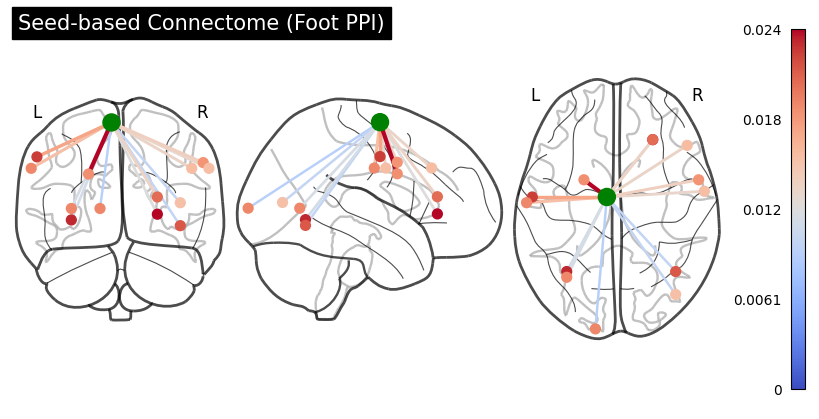

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
from matplotlib import colormaps
from matplotlib.colors import Normalize

# p = 0.02
coordinates_t = [
    (26,  32,   2, 4.17),
    (26,  32,  14, 3.54),
    (-34, -60,  -2, 4.03),
    (-34, -64,   6, 3.30),
    (-58,  -8,  42, 3.90),
    (-62, -12,  34, 3.30),
    (42, -60,  -6, 3.71),
    (-14, -100,  6, 3.31),
    (-22,   4,  30, 3.24),
    (58,   4,  38, 3.19),
    (62,  -4,  34, 2.70),
    (50,  28,  34, 2.71),
    (42, -76,  10, 2.67)
]

# 1) Definiamo il seed
seed_coord = (-6, -8, 66)
seed_t     = 0.0  # eventualmente sostituisci con il T‐value del seed

# 2) Se il seed non è già nella lista, lo aggiungiamo
coords_list = [(x, y, z) for x,y,z,_ in coordinates_t]
if seed_coord not in coords_list:
    coordinates_t.append((*seed_coord, seed_t))
    coords_list.append(seed_coord)

# 3) Ricostruiamo arrays numpy
coords = np.array([c[:3] for c in coordinates_t])
t_vals = np.array([c[3]   for c in coordinates_t])

# 4) Troviamo l’indice esatto del seed (ora garantito presente)
seed_idx = coords_list.index(seed_coord) if seed_coord in coords_list else len(coords)-1

# 5) Costruiamo la matrice di connessione seed‐based
N = len(coords)
connectome = np.zeros((N, N))
for i in range(N):
    if i != seed_idx:
        dist = np.linalg.norm(coords[i] - coords[seed_idx])
        connectome[seed_idx, i] = connectome[i, seed_idx] = 1.0 / dist

# 6) Prepariamo i colori (Reds per T, seed in verde)
norm        = Normalize(vmin=t_vals.min(), vmax=t_vals.max())
cmap        = colormaps['coolwarm']
node_colors = [cmap(norm(tv)) for tv in t_vals]
node_colors[seed_idx] = 'green'

# === Dimensioni dei nodi ===
default_size   =  50      # dimensione standard
highlight_size = 150      # dimensione per il seed
node_sizes = [default_size] * N
node_sizes[seed_idx] = highlight_size

# 7) Plot finale
fig = plt.figure(figsize=(8, 4))
display = plotting.plot_connectome(
    connectome,
    coords,
    node_color     = node_colors,
    node_size      = node_sizes,
    edge_threshold = '0%',
    edge_cmap      = 'coolwarm',
    edge_vmin      = 0.0,
    edge_vmax      = np.max(connectome),
    display_mode   = 'ortho',
    figure         = fig,
    title          = "Seed-based Connectome (Foot PPI)"
)
plt.show()

#PPI-LipsDX+LipsSX

/tmp/ipython-input-5-2351610011.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


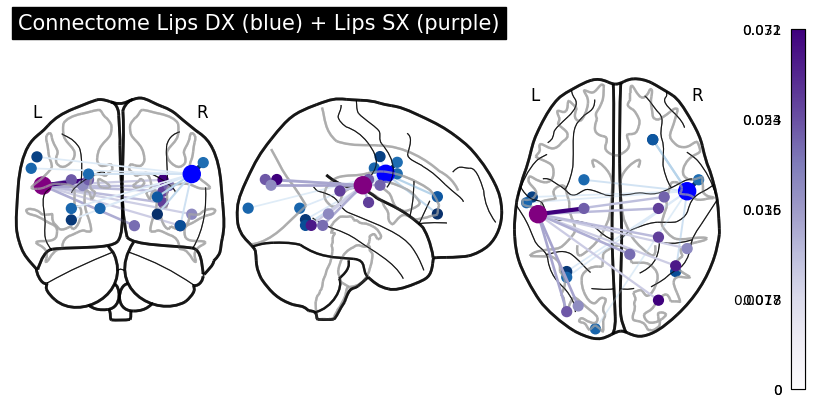

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
from matplotlib import colormaps
from matplotlib.colors import Normalize

# ——————————————————————————————————————
# 1) Due liste di (x,y,z,T)

coords_dx = [
    (26,  32,   2, 4.17),
    (26,  32,  14, 3.54),
    (-34, -60,  -2, 4.03),
    (-34, -64,   6, 3.30),
    (-58,  -8,  42, 3.90),
    (-62, -12,  34, 3.30),
    (42, -60,  -6, 3.71),
    (-14, -100,  6, 3.31),
    (-22,   4,  30, 3.24),
    (58,   4,  38, 3.19)
]
coords_sx = [
    (30, -80,  26, 5.97),
    (42, -56,  -6, 5.50),
    (50, -44,   2, 3.42),
    (30, -16,  10, 4.81),
    (30, -36,  18, 4.81),
    (-34, -88,  26, 4.36),
    (-26, -84,  22, 3.35),
    (-22, -16,  26, 4.25),
    (34,  -8,  22, 4.19),
    (10, -48,  -6, 3.99)
]

seed_dx = (50, -4, 30)
seed_sx = (-54, -20, 22)

# Assicuriamoci di avere esplicitamente i seed in lista (T=0)
for lst, seed in ((coords_dx, seed_dx), (coords_sx, seed_sx)):
    if seed not in [c[:3] for c in lst]:
        lst.append((*seed, 0.0))

# Funzione che restituisce coords_arr, t_vals, connectome e seed_idx
def prep(coord_list, seed):
    coords_arr = np.array([c[:3] for c in coord_list])
    t_vals     = np.array([c[3]   for c in coord_list])
    seed_idx   = [tuple(c[:3]) for c in coord_list].index(seed)
    N = len(coords_arr)
    C = np.zeros((N, N))
    for i in range(N):
        if i != seed_idx:
            d = np.linalg.norm(coords_arr[i] - coords_arr[seed_idx])
            C[seed_idx,i] = C[i,seed_idx] = 1.0 / d
    return coords_arr, t_vals, C, seed_idx

coords_arr_dx, t_dx, C_dx, idx_dx = prep(coords_dx, seed_dx)
coords_arr_sx, t_sx, C_sx, idx_sx = prep(coords_sx, seed_sx)

# Palette & colori nodi
norm_dx    = Normalize(vmin=t_dx.min(), vmax=t_dx.max())
norm_sx    = Normalize(vmin=t_sx.min(), vmax=t_sx.max())
cmap_dx    = colormaps['Blues']
cmap_sx    = colormaps['Purples']

node_colors_dx = [cmap_dx(norm_dx(tv)) for tv in t_dx]
node_colors_sx = [cmap_sx(norm_sx(tv)) for tv in t_sx]
node_colors_dx[idx_dx] = 'blue'
node_colors_sx[idx_sx] = 'purple'

# === Dimensioni dei nodi ===
default_size   =  50    # dimensione standard
highlight_size = 150    # dimensione per ciascun seed

# Creiamo due liste di dimensioni, una per DX e una per SX
node_sizes_dx = [default_size] * len(coords_arr_dx)
node_sizes_sx = [default_size] * len(coords_arr_sx)
node_sizes_dx[idx_dx] = highlight_size
node_sizes_sx[idx_sx] = highlight_size

# ——————————————————————————————————————
# 4) Plot UNA SOLA volta, sovrapponendo DX+SX

fig = plt.figure(figsize=(8, 4))

# Primo grafo: Lips DX in blu
plotting.plot_connectome(
    C_dx, coords_arr_dx,
    node_color     = node_colors_dx,
    node_size      = node_sizes_dx,    # ← aggiunto
    edge_threshold = '0%',
    edge_cmap      = 'Blues',
    edge_vmin      = 0.0,
    edge_vmax      = C_dx.max(),
    display_mode   = 'ortho',
    figure         = fig,
    title          = "Connectome Lips DX (blue) + Lips SX (purple)"
)

# Secondo grafo: Lips SX in viola, *senza* ridefinire il layout
plotting.plot_connectome(
    C_sx, coords_arr_sx,
    node_color     = node_colors_sx,
    node_size      = node_sizes_sx,    # ← aggiunto
    edge_threshold = '0%',
    edge_cmap      = 'Purples',
    edge_vmin      = 0.0,
    edge_vmax      = C_sx.max(),
    display_mode   = 'ortho',
    figure         = fig
)

plt.tight_layout()
plt.show()